# Logistic Regression with Optuna Hyperparameter Tuning

This notebook trains a Logistic Regression model with:
- Custom data preprocessing
- Feature engineering
- Optuna hyperparameter optimization
- Model evaluation and predictions

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data

In [5]:
# Load training and test data
train_df = pd.read_csv('../dataset/train_dropped_column.csv')
test_df = pd.read_csv('../dataset/test_dropped_column.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTarget distribution:")
print(train_df['retention_status'].value_counts())
print(f"\nClass balance: {train_df['retention_status'].value_counts(normalize=True)}")

Training data shape: (59608, 23)
Test data shape: (14900, 22)

Target distribution:
retention_status
Stayed    31264
Left      28344
Name: count, dtype: int64

Class balance: retention_status
Stayed    0.524493
Left      0.475507
Name: proportion, dtype: float64


## 2. Data Preprocessing & Feature Engineering

In [6]:
def preprocess_and_engineer_features(df, is_train=True):
    """
    Preprocess data and engineer features for Logistic Regression
    """
    df = df.copy()
    
    # Save founder_id for later
    founder_ids = df['founder_id'].copy()
    
    # Drop founder_id as it's not a feature
    df = df.drop('founder_id', axis=1)
    
    # Separate target if training data
    if is_train and 'retention_status' in df.columns:
        target = df['retention_status'].copy()
        df = df.drop('retention_status', axis=1)
    else:
        target = None
    
    # --- Feature Engineering ---
    
    # 1. Revenue per year with startup
    df['revenue_per_year'] = df['monthly_revenue_generated'] / (df['years_with_startup'] + 1)
    
    # 2. Age-related features
    df['age_when_joined'] = df['founder_age'] - df['years_with_startup']
    df['is_young_founder'] = (df['founder_age'] < 30).astype(int)
    df['is_senior_founder'] = (df['founder_age'] > 50).astype(int)
    
    # 3. Experience ratio
    df['experience_ratio'] = df['years_with_startup'] / (df['founder_age'] + 1)
    
    # 4. Work-life indicators
    df['overtime_long_tenure'] = ((df['working_overtime'] == 'Yes') & (df['years_with_startup'] > 10)).astype(int)
    
    # 5. Performance composite score
    performance_mapping = {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4}
    satisfaction_mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
    balance_mapping = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
    
    df['performance_score'] = df['startup_performance_rating'].map(performance_mapping)
    df['satisfaction_score'] = df['venture_satisfaction'].map(satisfaction_mapping)
    df['balance_score'] = df['work_life_balance_rating'].map(balance_mapping)
    
    df['composite_score'] = (df['performance_score'] + df['satisfaction_score'] + df['balance_score']) / 3
    
    # 6. Location factor
    df['near_investor_hub'] = (df['distance_from_investor_hub'] < 30).astype(int)
    
    # 7. Leadership experience
    df['leadership_funding_experience'] = df['funding_rounds_led'] * df['years_with_startup']
    
    # 8. Family commitment
    df['has_dependents'] = (df['num_dependents'] > 0).astype(int)
    df['family_size'] = df['num_dependents'] + 1  # Include founder
    
    # 9. Education level encoding
    education_order = {'High School': 1, 'Associate Degree': 2, 'Bachelor\'s Degree': 3, 
                      'Master\'s Degree': 4, 'PhD': 5}
    df['education_level'] = df['education_background'].map(education_order)
    
    # 10. Team and reputation interaction
    team_size_mapping = {'Small': 1, 'Medium': 2, 'Large': 3}
    reputation_mapping = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
    visibility_mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
    
    df['team_size_numeric'] = df['team_size_category'].map(team_size_mapping)
    df['reputation_numeric'] = df['startup_reputation'].map(reputation_mapping)
    df['visibility_numeric'] = df['founder_visibility'].map(visibility_mapping)
    
    df['team_reputation_score'] = df['team_size_numeric'] * df['reputation_numeric']
    
    # 11. Binary feature combinations
    df['remote_innovation'] = ((df['remote_operations'] == 'Yes') & (df['innovation_support'] == 'Yes')).astype(int)
    df['leadership_innovation'] = ((df['leadership_scope'] == 'Yes') & (df['innovation_support'] == 'Yes')).astype(int)
    
    # --- Encoding Categorical Variables ---
    
    # Binary encoding for Yes/No columns
    binary_cols = ['working_overtime', 'remote_operations', 'leadership_scope', 'innovation_support']
    for col in binary_cols:
        df[col] = (df[col] == 'Yes').astype(int)
    
    # One-hot encoding for categorical features
    categorical_cols = ['founder_gender', 'founder_role', 'personal_status', 'startup_stage']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    # Drop original ordinal columns that have been encoded
    cols_to_drop = ['work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating',
                    'education_background', 'team_size_category', 'startup_reputation', 'founder_visibility']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    # Handle any remaining missing values
    df = df.fillna(df.median(numeric_only=True))
    
    return df, target, founder_ids

# Preprocess data
X_train, y_train, train_ids = preprocess_and_engineer_features(train_df, is_train=True)
X_test, _, test_ids = preprocess_and_engineer_features(test_df, is_train=False)

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

print(f"\nPreprocessed training features shape: {X_train.shape}")
print(f"Preprocessed test features shape: {X_test.shape}")
print(f"\nFeature names: {X_train.columns.tolist()[:10]}...")  # Show first 10


Preprocessed training features shape: (59608, 40)
Preprocessed test features shape: (14900, 40)

Feature names: ['founder_age', 'years_with_startup', 'monthly_revenue_generated', 'funding_rounds_led', 'working_overtime', 'distance_from_investor_hub', 'num_dependents', 'remote_operations', 'leadership_scope', 'innovation_support']...


In [7]:
# Align test set columns with training set
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

extra_cols = set(X_test.columns) - set(X_train.columns)
X_test = X_test.drop(columns=list(extra_cols))

# Ensure same column order
X_test = X_test[X_train.columns]

print(f"Aligned test features shape: {X_test.shape}")

Aligned test features shape: (14900, 40)


## 3. Feature Scaling

In [8]:
# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


## 4. Train-Validation Split

In [9]:
# Split data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_encoded
)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")

Training set: (47686, 40)
Validation set: (11922, 40)


## 5. Optuna Hyperparameter Tuning

In [10]:
def objective(trial):
    """
    Objective function for Optuna optimization
    """
    # Suggest hyperparameters
    params = {
        'C': trial.suggest_float('C', 0.001, 100, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet']),
        'solver': trial.suggest_categorical('solver', ['saga']),  # saga supports all penalties
        'max_iter': trial.suggest_int('max_iter', 100, 1000),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state': RANDOM_STATE
    }
    
    # Add l1_ratio for elasticnet
    if params['penalty'] == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    # Train model with cross-validation
    model = LogisticRegression(**params)
    
    # Use stratified k-fold cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_split, y_train_split, cv=cv, scoring='accuracy', n_jobs=-1)
    
    return scores.mean()

# Create Optuna study
print("Starting Optuna hyperparameter optimization...\n")
study = optuna.create_study(direction='maximize', study_name='logistic_regression_optimization')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n{'='*50}")
print("Optimization Complete!")
print(f"{'='*50}")
print(f"Best accuracy: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-26 20:49:02,991] A new study created in memory with name: logistic_regression_optimization


Starting Optuna hyperparameter optimization...



Best trial: 0. Best value: 0.742461:   2%|▏         | 1/50 [00:03<03:00,  3.67s/it]

[I 2025-11-26 20:49:06,674] Trial 0 finished with value: 0.7424610174501521 and parameters: {'C': 10.920811202484002, 'penalty': 'elasticnet', 'solver': 'saga', 'max_iter': 717, 'class_weight': None, 'l1_ratio': 0.16695573915717143}. Best is trial 0 with value: 0.7424610174501521.


Best trial: 1. Best value: 0.742943:   4%|▍         | 2/50 [00:05<02:12,  2.75s/it]

...

[I 2025-11-26 20:51:22,249] Trial 47 finished with value: 0.7428804541440865 and parameters: {'C': 0.021589771192763764, 'penalty': 'elasticnet', 'solver': 'saga', 'max_iter': 275, 'class_weight': 'balanced', 'l1_ratio': 0.09258851683097859}. Best is trial 36 with value: 0.7430692103305239.


Best trial: 36. Best value: 0.743069:  98%|█████████▊| 49/50 [02:19<00:01,  1.53s/it]

[I 2025-11-26 20:51:22,878] Trial 48 finished with value: 0.7420206647678477 and parameters: {'C': 0.0013612515340289363, 'penalty': 'elasticnet', 'solver': 'saga', 'max_iter': 395, 'class_weight': None, 'l1_ratio': 0.013132469982577832}. Best is trial 36 with value: 0.7430692103305239.


Best trial: 36. Best value: 0.743069: 100%|██████████| 50/50 [02:21<00:00,  2.84s/it]

[I 2025-11-26 20:51:24,782] Trial 49 finished with value: 0.7424610592249634 and parameters: {'C': 0.013025730576222645, 'penalty': 'elasticnet', 'solver': 'saga', 'max_iter': 330, 'class_weight': 'balanced', 'l1_ratio': 0.2792833540848195}. Best is trial 36 with value: 0.7430692103305239.

Optimization Complete!
Best accuracy: 0.7431

Best hyperparameters:
  C: 0.0074526034164071695
  penalty: elasticnet
  solver: saga
  max_iter: 271
  class_weight: balanced
  l1_ratio: 0.006305678794888081


In [13]:
# Visualize optimization history
try:
    fig = plot_optimization_history(study)
    fig.show()
    
    # Visualize parameter importances
    fig = plot_param_importances(study)
    fig.show()
except ImportError:
    print("Plotly not installed. Skipping visualizations.")
    print("To install: pip install plotly kaleido")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [12]:
# Analyze optimization results
trials_df = study.trials_dataframe()

# Sort by objective value (accuracy) descending
trials_df = trials_df.sort_values('value', ascending=False)

print("Top 5 Hyperparameter Combinations:")
# Select columns starting with 'params_' and the 'value' column
display_cols = ['number', 'value'] + [col for col in trials_df.columns if col.startswith('params_')]
print(trials_df[display_cols].head(5))

# Save trials to CSV for future reference
trials_df.to_csv('optuna_trials_history.csv', index=False)
print("\nOptimization history saved to 'optuna_trials_history.csv'")

Top 5 Hyperparameter Combinations:
    number     value  params_C params_class_weight  params_l1_ratio  \
36      36  0.743069  0.007453            balanced         0.006306   
39      39  0.742985  0.004974            balanced         0.001766   
35      35  0.742985  0.040477            balanced         0.055184   
38      38  0.742985  0.020116            balanced         0.016038   
34      34  0.742964  0.032686            balanced              NaN   

    params_max_iter params_penalty params_solver  
36              271     elasticnet          saga  
39              108     elasticnet          saga  
35              243     elasticnet          saga  
38              107     elasticnet          saga  
34              393             l2          saga  

Optimization history saved to 'optuna_trials_history.csv'


## 6. Train Final Model with Best Parameters

In [14]:
# Train final model with best parameters
best_params = study.best_params.copy()
best_params['random_state'] = RANDOM_STATE
best_params['solver'] = 'saga'

final_model = LogisticRegression(**best_params)
final_model.fit(X_train_split, y_train_split)

print("Final model trained successfully!")

Final model trained successfully!


## 7. Model Evaluation

In [15]:
# Make predictions on validation set
y_val_pred = final_model.predict(X_val_split)
y_val_pred_proba = final_model.predict_proba(X_val_split)

# Calculate metrics
val_accuracy = accuracy_score(y_val_split, y_val_pred)
val_roc_auc = roc_auc_score(y_val_split, y_val_pred_proba[:, 1])

print(f"{'='*50}")
print("Validation Set Performance")
print(f"{'='*50}")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"ROC AUC Score: {val_roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val_split, y_val_pred, target_names=le.classes_))

Validation Set Performance
Accuracy: 0.7405
ROC AUC Score: 0.8291

Classification Report:
              precision    recall  f1-score   support

        Left       0.72      0.74      0.73      5669
      Stayed       0.76      0.74      0.75      6253

    accuracy                           0.74     11922
   macro avg       0.74      0.74      0.74     11922
weighted avg       0.74      0.74      0.74     11922



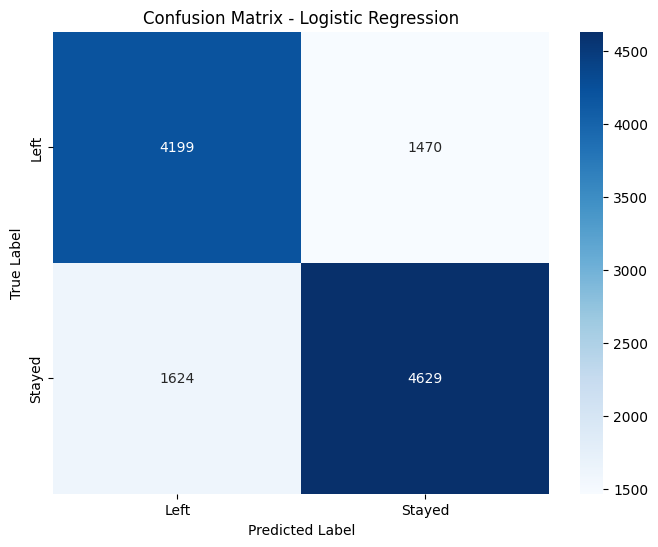

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_val_split, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

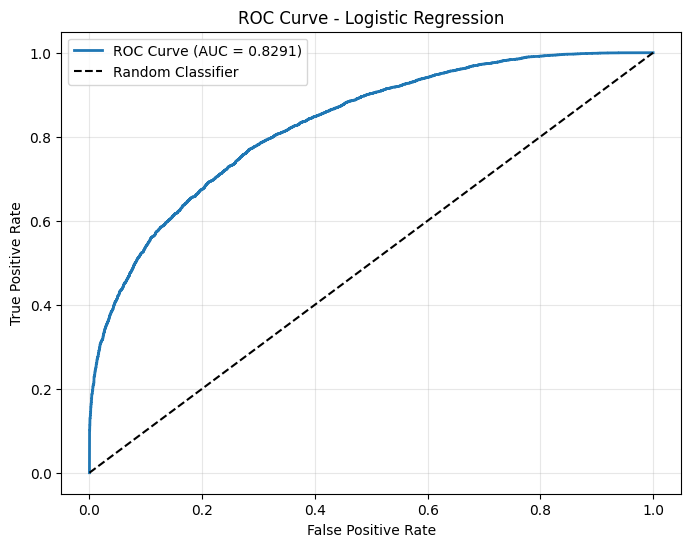

In [17]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val_split, y_val_pred_proba[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {val_roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

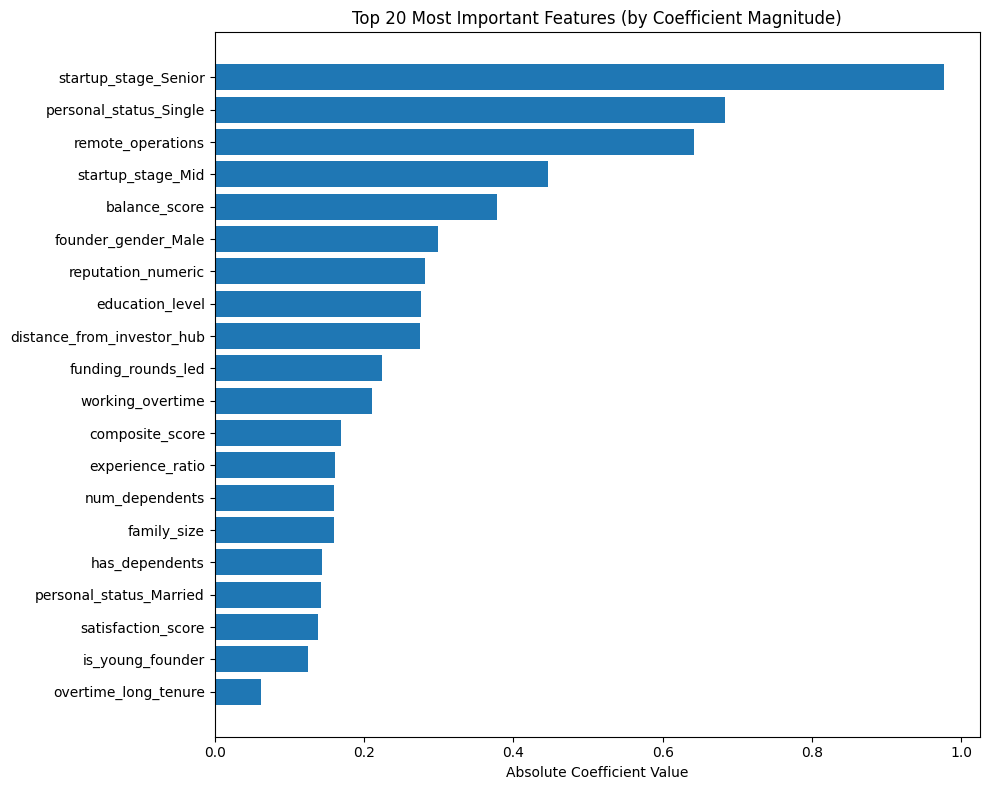


Top 20 Most Important Features:
                   feature  coefficient
      startup_stage_Senior     0.976295
    personal_status_Single     0.683237
         remote_operations     0.642101
         startup_stage_Mid     0.446387
             balance_score     0.378419
       founder_gender_Male     0.298472
        reputation_numeric     0.281736
           education_level     0.276547
distance_from_investor_hub     0.275612
        funding_rounds_led     0.223914
          working_overtime     0.210888
           composite_score     0.168809
          experience_ratio     0.161781
            num_dependents     0.159909
               family_size     0.159909
            has_dependents     0.143213
   personal_status_Married     0.141983
        satisfaction_score     0.138949
          is_young_founder     0.125322
      overtime_long_tenure     0.061652


In [18]:
# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': np.abs(final_model.coef_[0])
}).sort_values('coefficient', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['coefficient'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Most Important Features (by Coefficient Magnitude)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Features:")
print(feature_importance.to_string(index=False))

## 8. Retrain on Full Training Data

In [19]:
# Retrain on full training data for final predictions
print("Retraining model on full training data...")
final_model.fit(X_train_scaled, y_train_encoded)
print("Model retrained successfully!")

Retraining model on full training data...
Model retrained successfully!
Model retrained successfully!


## 9. Generate Test Predictions

In [20]:
# Make predictions on test set
y_test_pred = final_model.predict(X_test_scaled)
y_test_pred_proba = final_model.predict_proba(X_test_scaled)

# Convert predictions back to original labels
y_test_pred_labels = le.inverse_transform(y_test_pred)

print(f"Test predictions generated!")
print(f"Prediction distribution:")
print(pd.Series(y_test_pred_labels).value_counts())

Test predictions generated!
Prediction distribution:
Stayed    7592
Left      7308
Name: count, dtype: int64


## 10. Save Predictions

In [21]:
# Create submission file with probabilities
submission_probs = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred_labels,
    'probability_Left': y_test_pred_proba[:, 0],
    'probability_Stayed': y_test_pred_proba[:, 1]
})

submission_probs.to_csv('logistic_regression_predictions_with_probs.csv', index=False)
print("\nPredictions with probabilities saved to 'logistic_regression_predictions_with_probs.csv'")

# Create standard submission file
submission = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred_labels
})

submission.to_csv('submission_logistic_regression.csv', index=False)
print("Submission file saved to 'submission_logistic_regression.csv'")

print("\nFirst few predictions:")
print(submission.head(10))


Predictions with probabilities saved to 'logistic_regression_predictions_with_probs.csv'
Submission file saved to 'submission_logistic_regression.csv'

First few predictions:
   founder_id retention_status
0       52685           Stayed
1       30585             Left
2       54656           Stayed
3       33442             Left
4       15667           Stayed
5        3496           Stayed
6       46775             Left
7       72645             Left
8        4941           Stayed
9       65181             Left


## 11. Model Summary

In [22]:
# Save model summary
summary = f"""
{'='*60}
LOGISTIC REGRESSION MODEL SUMMARY
{'='*60}

Dataset Information:
- Training samples: {len(X_train_scaled)}
- Test samples: {len(X_test_scaled)}
- Number of features: {X_train.shape[1]}

Best Hyperparameters:
{chr(10).join(f'- {k}: {v}' for k, v in best_params.items())}

Validation Performance:
- Accuracy: {val_accuracy:.4f}
- ROC AUC: {val_roc_auc:.4f}

Feature Engineering Applied:
- Revenue per year with startup
- Age-related features (young/senior founder indicators)
- Experience ratio
- Work-life balance indicators
- Performance composite score
- Location factors (distance from investor hub)
- Leadership experience metrics
- Family commitment features
- Education level encoding
- Team and reputation interactions
- Binary feature combinations

Preprocessing Steps:
1. Handled missing values with median imputation
2. Encoded categorical variables (one-hot encoding)
3. Created interaction features
4. Standardized features using StandardScaler

Optuna Optimization:
- Number of trials: 50
- Cross-validation folds: 5
- Best CV score: {study.best_value:.4f}

Output Files:
- logistic_regression_predictions_with_probs.csv
- submission_logistic_regression.csv
{'='*60}
"""

print(summary)

with open('logistic_regression_summary.txt', 'w') as f:
    f.write(summary)

print("\nModel summary saved to 'logistic_regression_summary.txt'")


LOGISTIC REGRESSION MODEL SUMMARY

Dataset Information:
- Training samples: 59608
- Test samples: 14900
- Number of features: 40

Best Hyperparameters:
- C: 0.0074526034164071695
- penalty: elasticnet
- solver: saga
- max_iter: 271
- class_weight: balanced
- l1_ratio: 0.006305678794888081
- random_state: 42

Validation Performance:
- Accuracy: 0.7405
- ROC AUC: 0.8291

Feature Engineering Applied:
- Revenue per year with startup
- Age-related features (young/senior founder indicators)
- Experience ratio
- Work-life balance indicators
- Performance composite score
- Location factors (distance from investor hub)
- Leadership experience metrics
- Family commitment features
- Education level encoding
- Team and reputation interactions
- Binary feature combinations

Preprocessing Steps:
1. Handled missing values with median imputation
2. Encoded categorical variables (one-hot encoding)
3. Created interaction features
4. Standardized features using StandardScaler

Optuna Optimization:
- Num